In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [ ]:
import os
import numpy as np
from data import constants
from alignment.signals import capnostream, mocap
import matplotlib.pyplot as plt

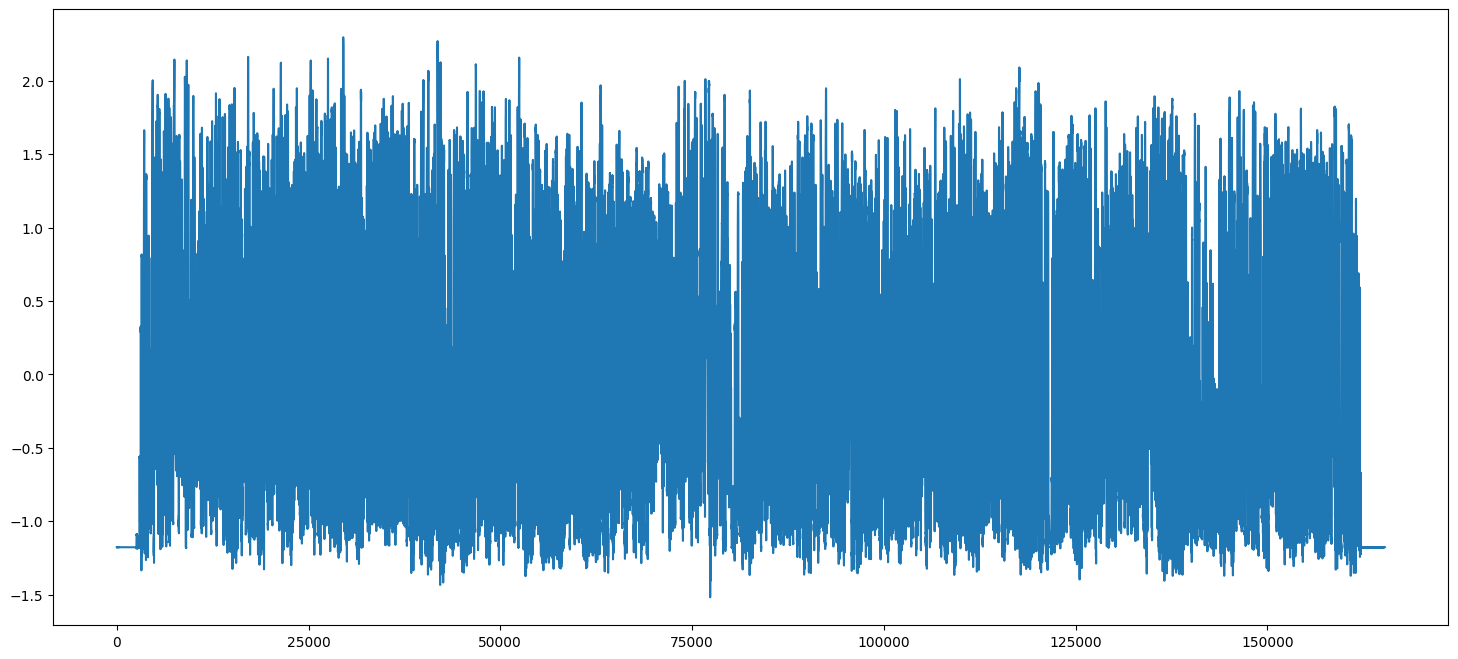

In [9]:
waveform = capnostream.from_file("co2.xlsx")

plt.figure(figsize=(18,8))
plt.plot(waveform)

/Users/paulb/Desktop/code/research/babi/alignment/signals/mocap.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


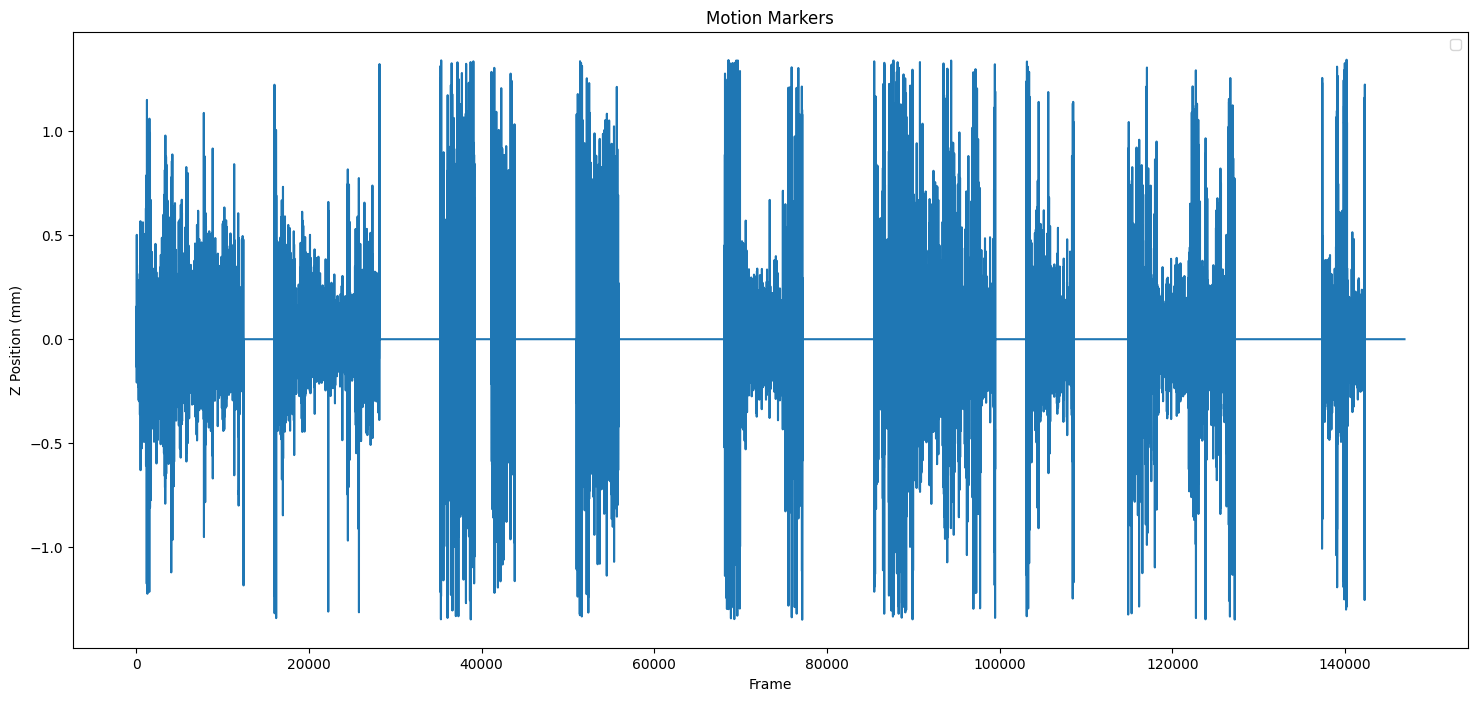

In [4]:
motions = mocap.from_package(os.path.join(constants.raw_data_dir, "package"))
mocap.plot(motions["CMid Z"].to_numpy())

In [5]:
print(f"[MOTION]: {motions.shape[1]} frames | {motions.shape[1] / mocap.sr:.2f}s ({mocap.sr}Hz)")
print(f"[WAVEFORM]: {waveform.shape[0]} frames | {waveform.shape[0] / capnostream.sr:.2f}s ({capnostream.sr}Hz)")

[MOTION]: 10 frames | 0.10s (100Hz)
[WAVEFORM]: 165320 frames | 8266.00s (20Hz)


In [6]:
import matplotlib.pyplot as plt
from scipy import signal

def align(motion: np.ndarray):
    plt.figure(figsize=(18, 20))

    t_waveform = np.arange(len(waveform)) / mocap.sr
    t_motion = np.arange(len(motion)) / mocap.sr

    plt.subplot(4, 1, 3)
    plt.title("Signal Comparison")
    plt.plot(t_waveform, waveform, label="Capnostream", color='blue', alpha=0.4)
    plt.plot(t_motion, motion, label="Motion (composite)", color='black')
    plt.xlabel("seconds")
    plt.legend(loc="upper right")
    plt.grid(True)

    correlation = signal.correlate(waveform, motion, mode='full')
    lags = signal.correlation_lags(len(waveform), len(motion), mode='full')

    peak_idx = np.argmin(correlation)
    calculated_shift = lags[peak_idx]
    calculated_shift_s = calculated_shift / mocap.sr

    true_shift = 360

    plt.subplot(4, 1, 4)
    plt.title(f"Cross-Correlation (Negative peak found at lag: {calculated_shift_s})")
    plt.plot(lags/mocap.sr, correlation, color='teal')
    plt.axvline(x=calculated_shift_s, color='red', label=f'Calculated Shift = {calculated_shift_s}')
    plt.axvline(x=true_shift, color='blue', label=f'True Shift = {true_shift}')
    plt.legend(loc="upper right")
    plt.grid(True)
    plt.xlabel("Lag")
    plt.ylabel("Correlation Score")

    plt.tight_layout()
    plt.show()

    print(f"True Time Shift introduced: {true_shift}")
    print(f"Calculated Shift via Correlation ({correlation[peak_idx]}): {calculated_shift_s}")

CMid Z


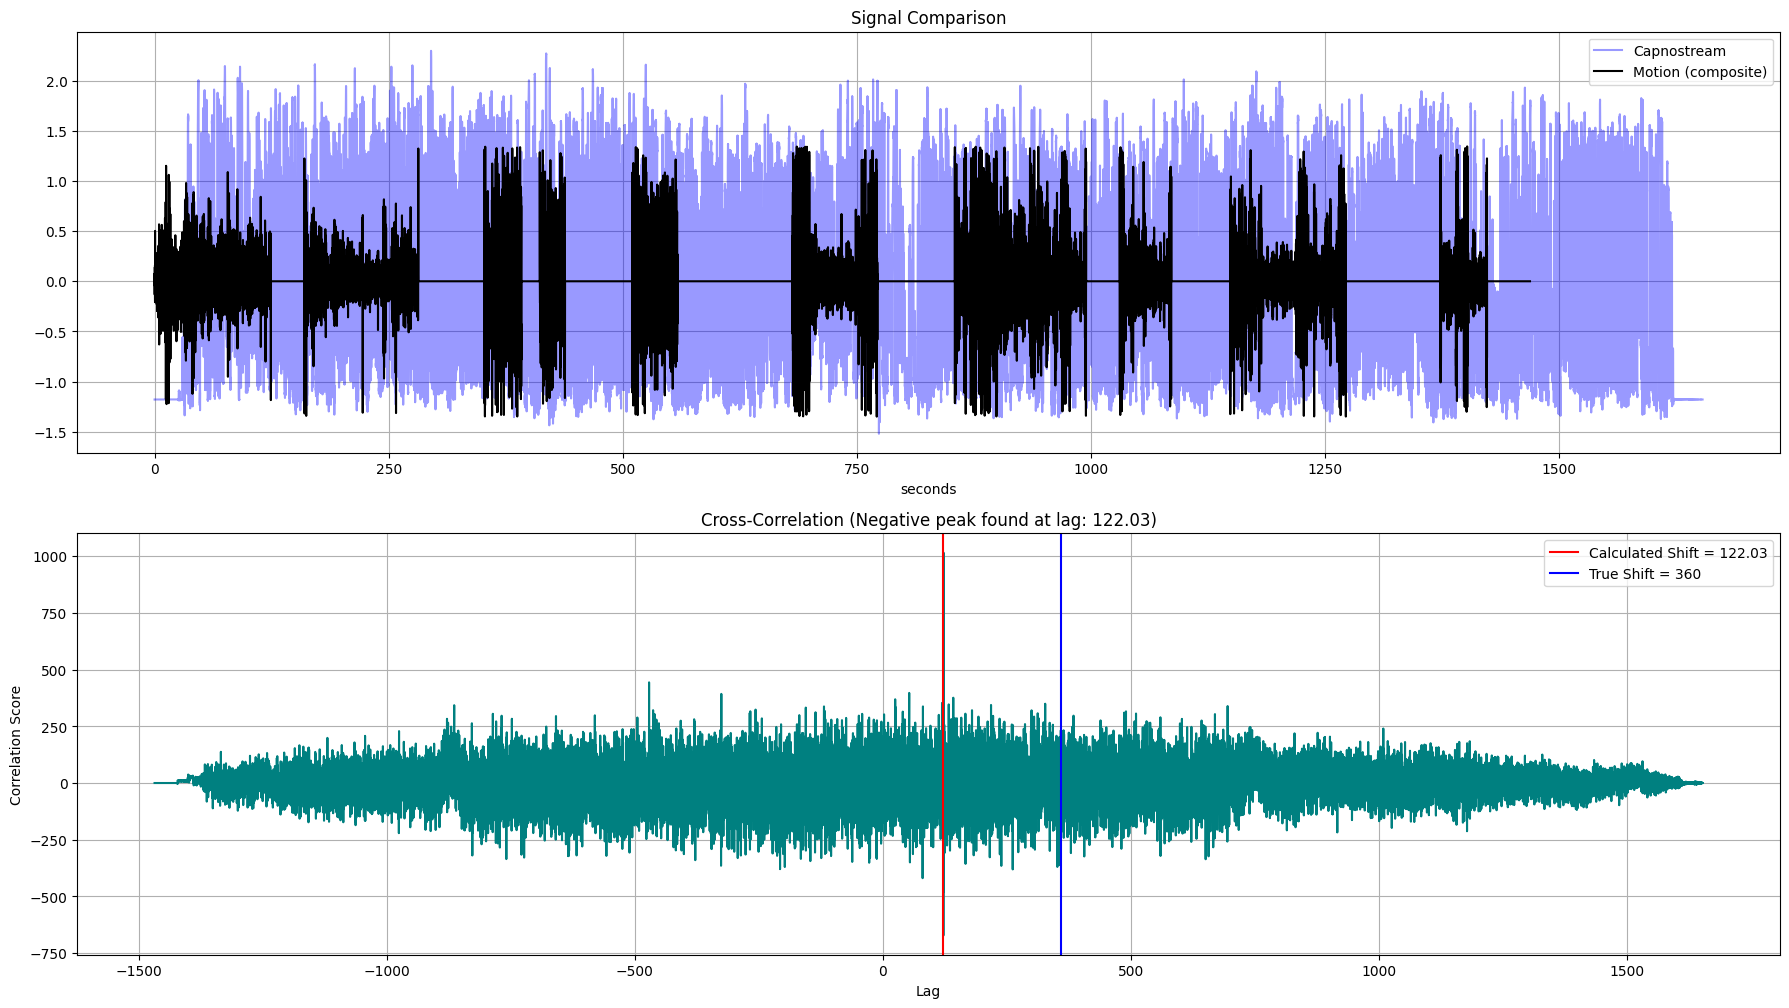

True Time Shift introduced: 360
Calculated Shift via Correlation (-672.9932971833293): 122.03
DMid Z


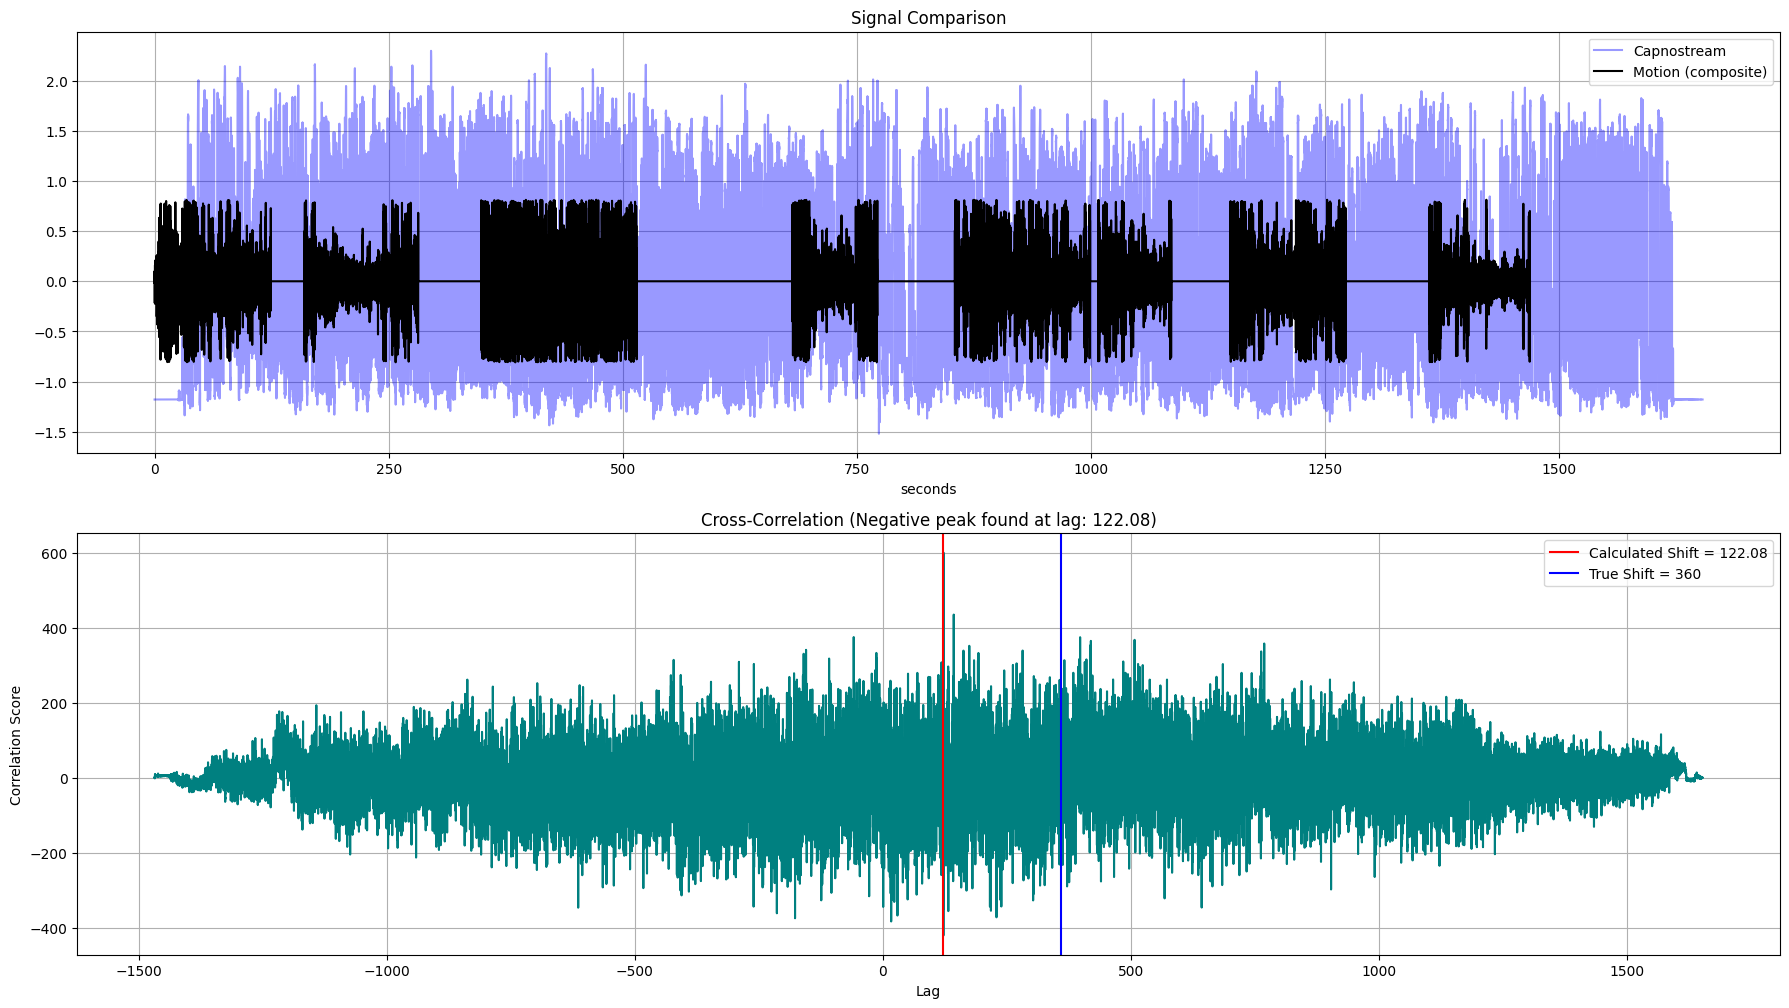

True Time Shift introduced: 360
Calculated Shift via Correlation (-420.20138410339564): 122.08
CL1 Z


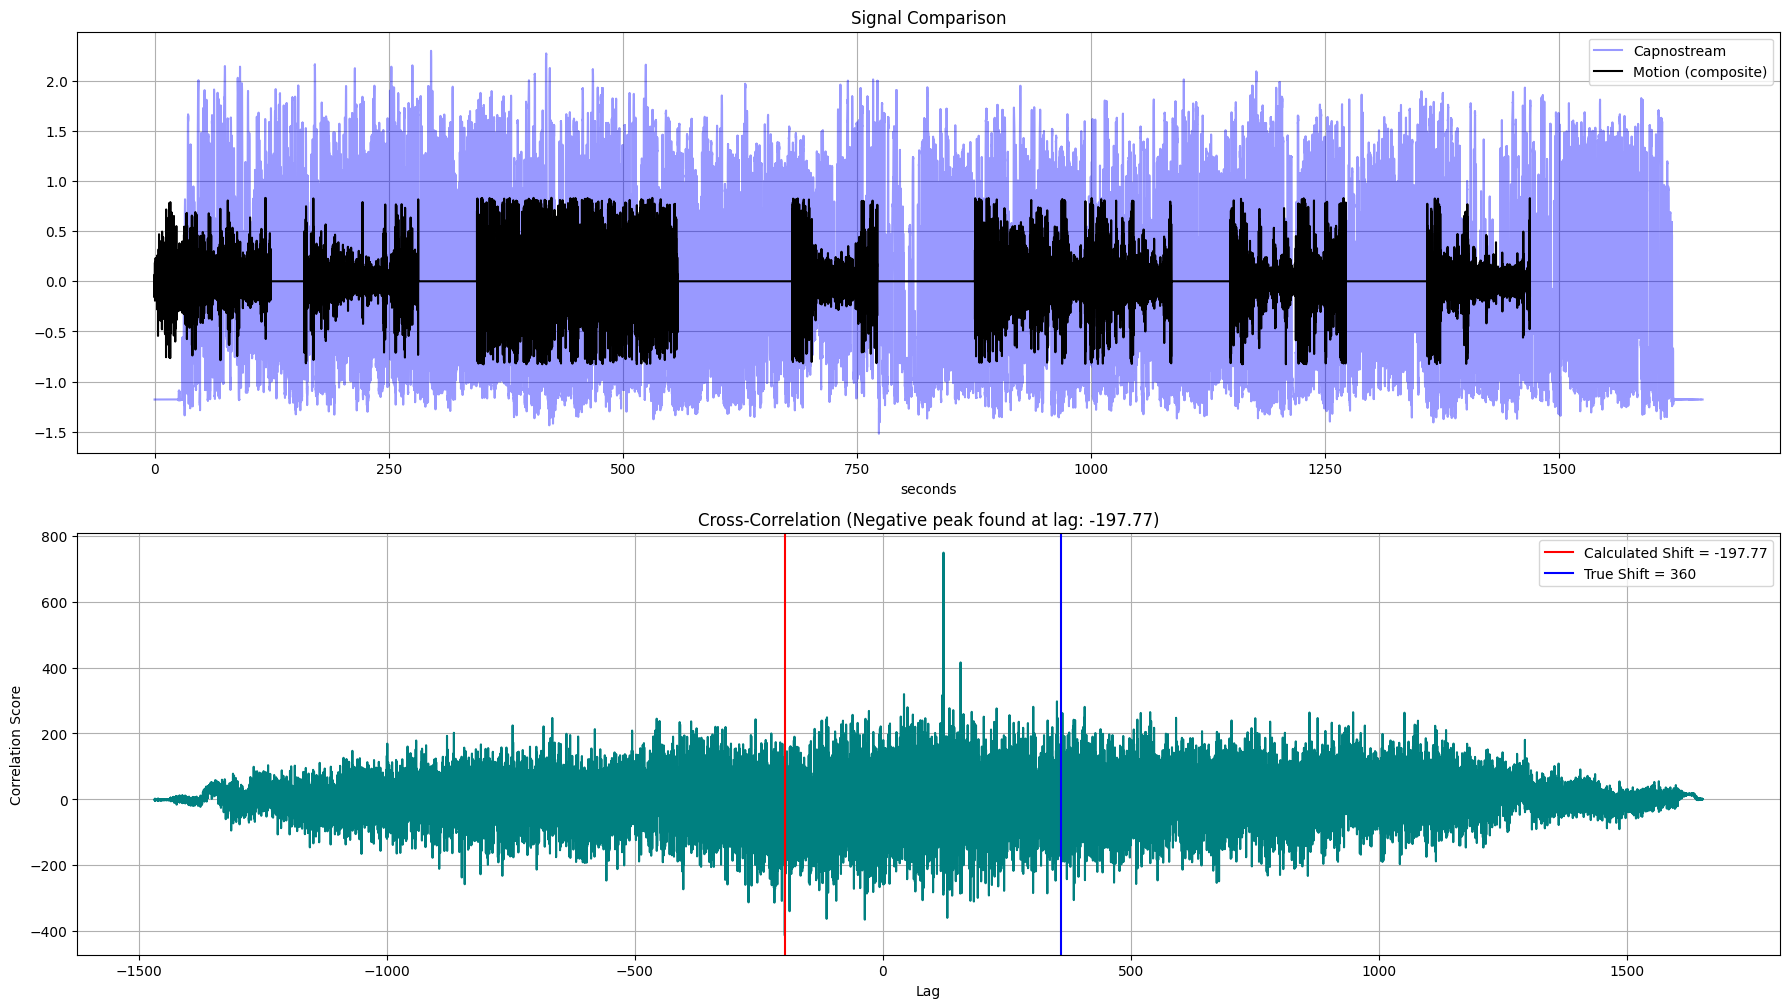

True Time Shift introduced: 360
Calculated Shift via Correlation (-413.81374643027675): -197.77
CL2 Z


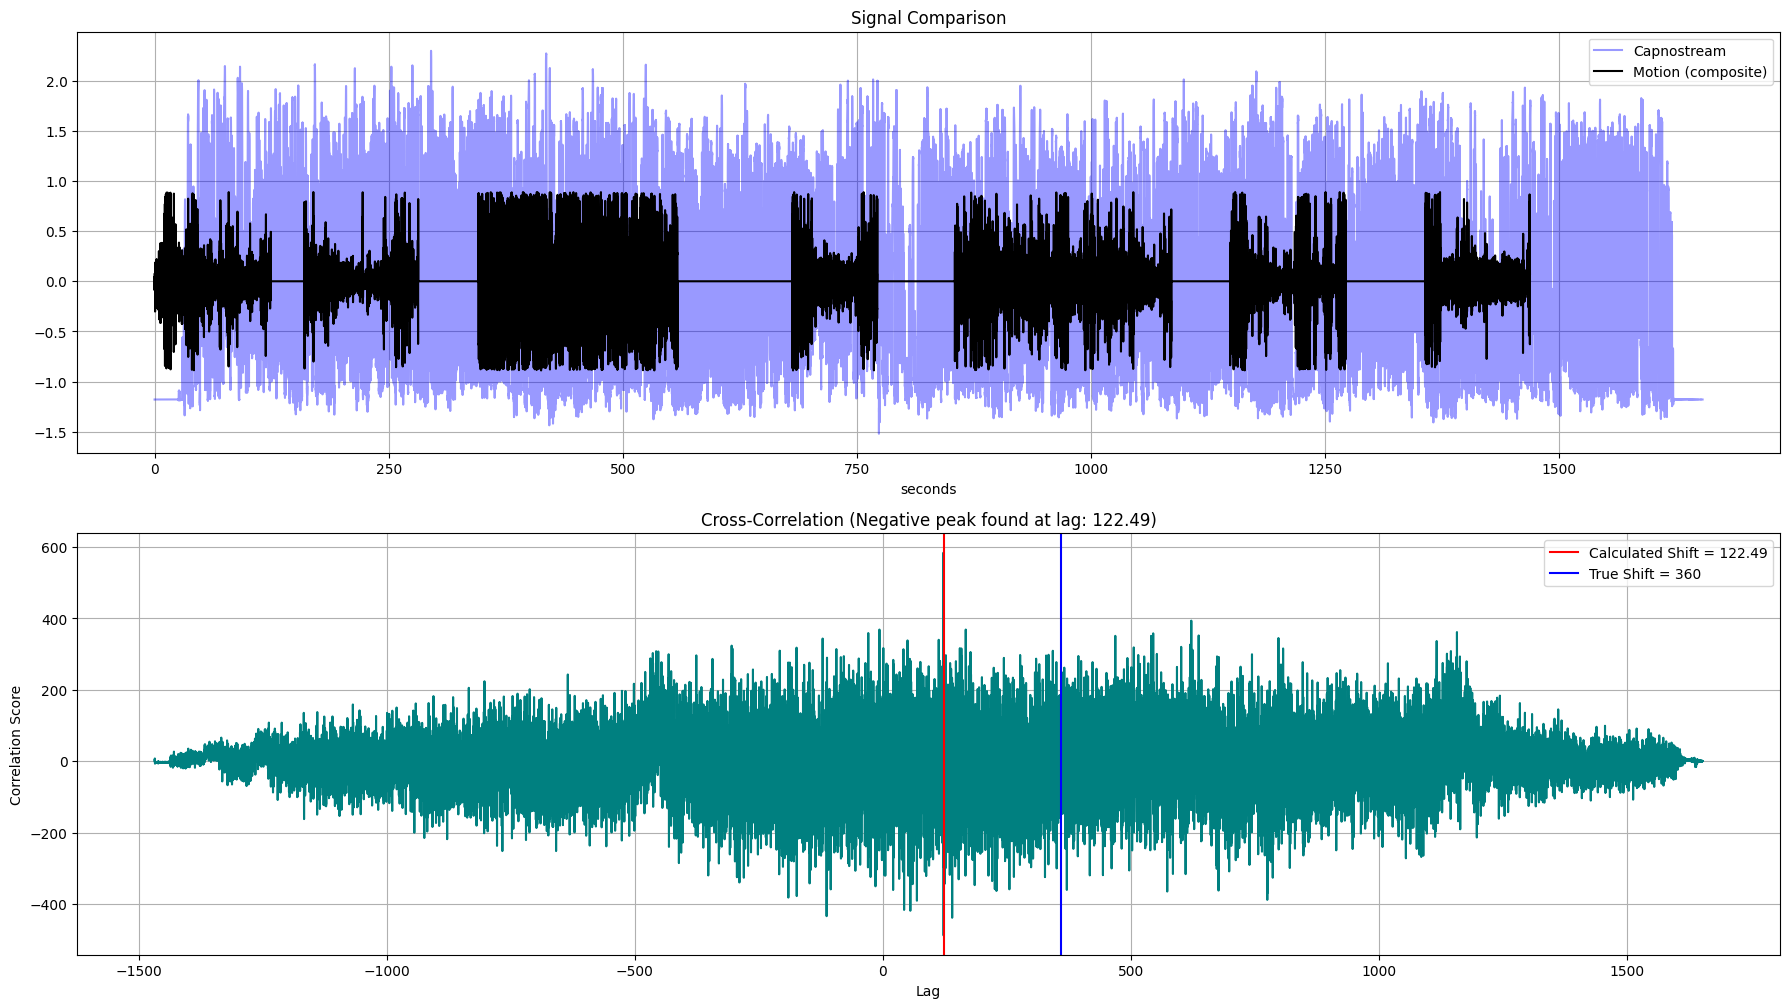

True Time Shift introduced: 360
Calculated Shift via Correlation (-488.56668720205914): 122.49
CR1 Z


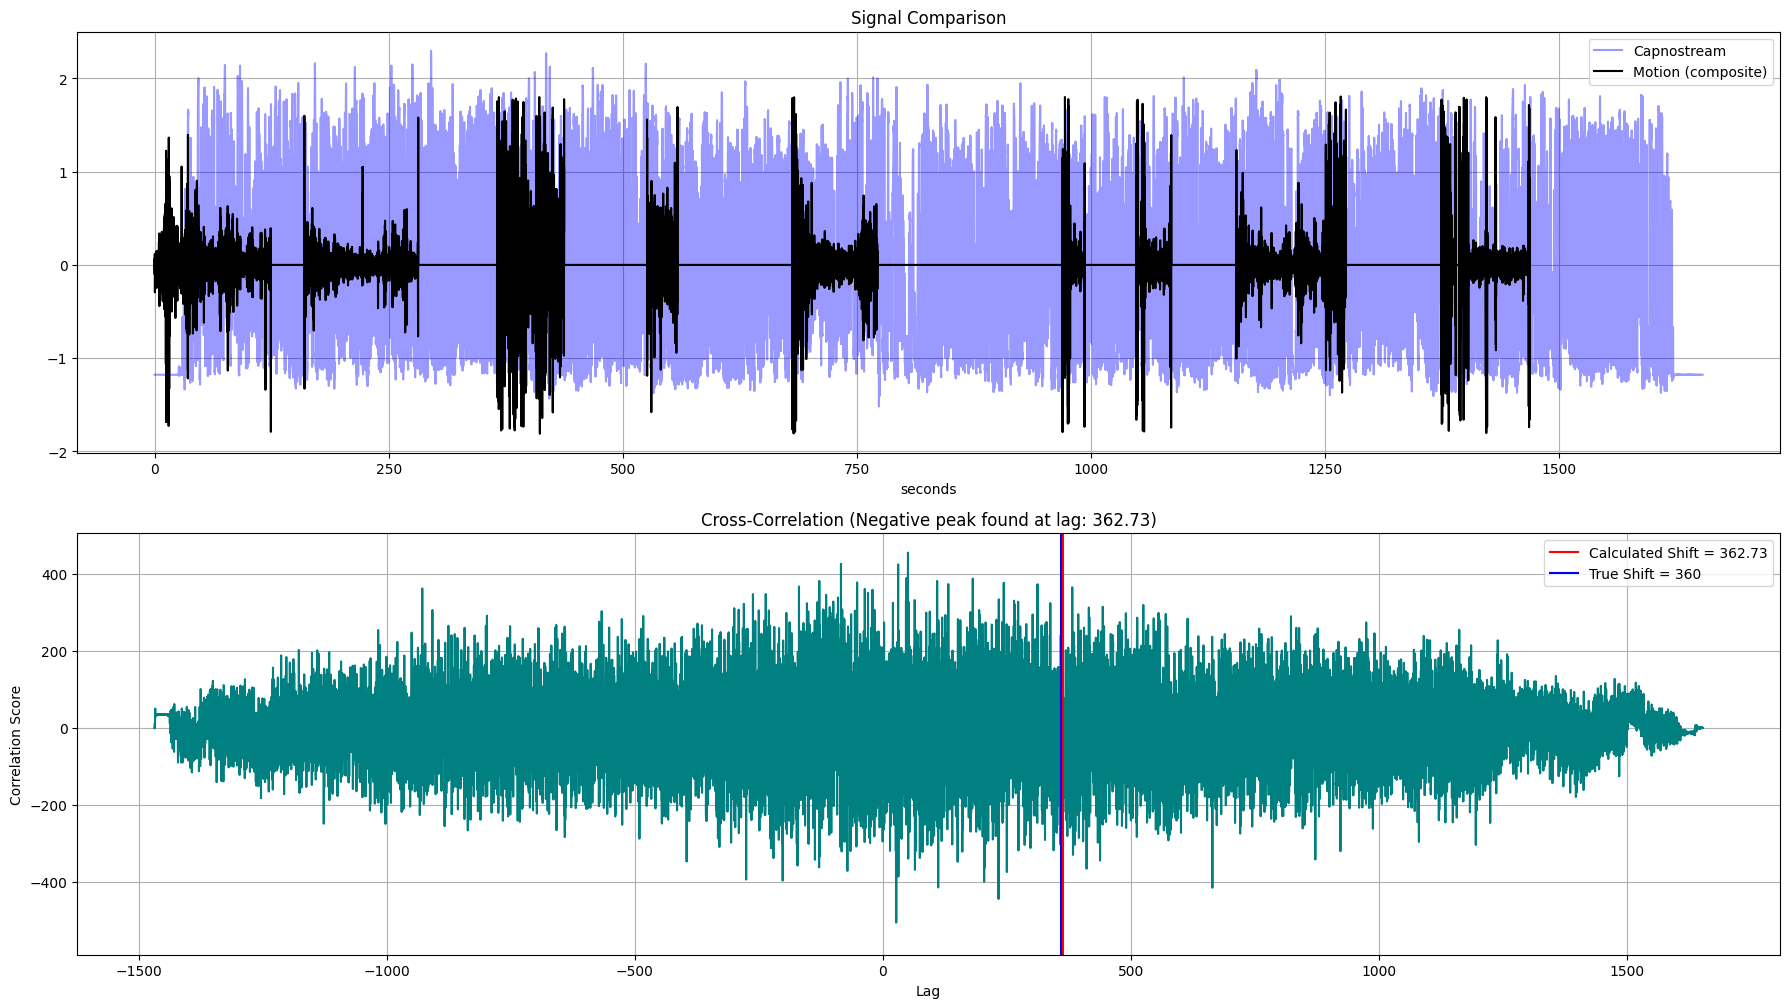

True Time Shift introduced: 360
Calculated Shift via Correlation (-538.8896624029422): 362.73
CR2 Z


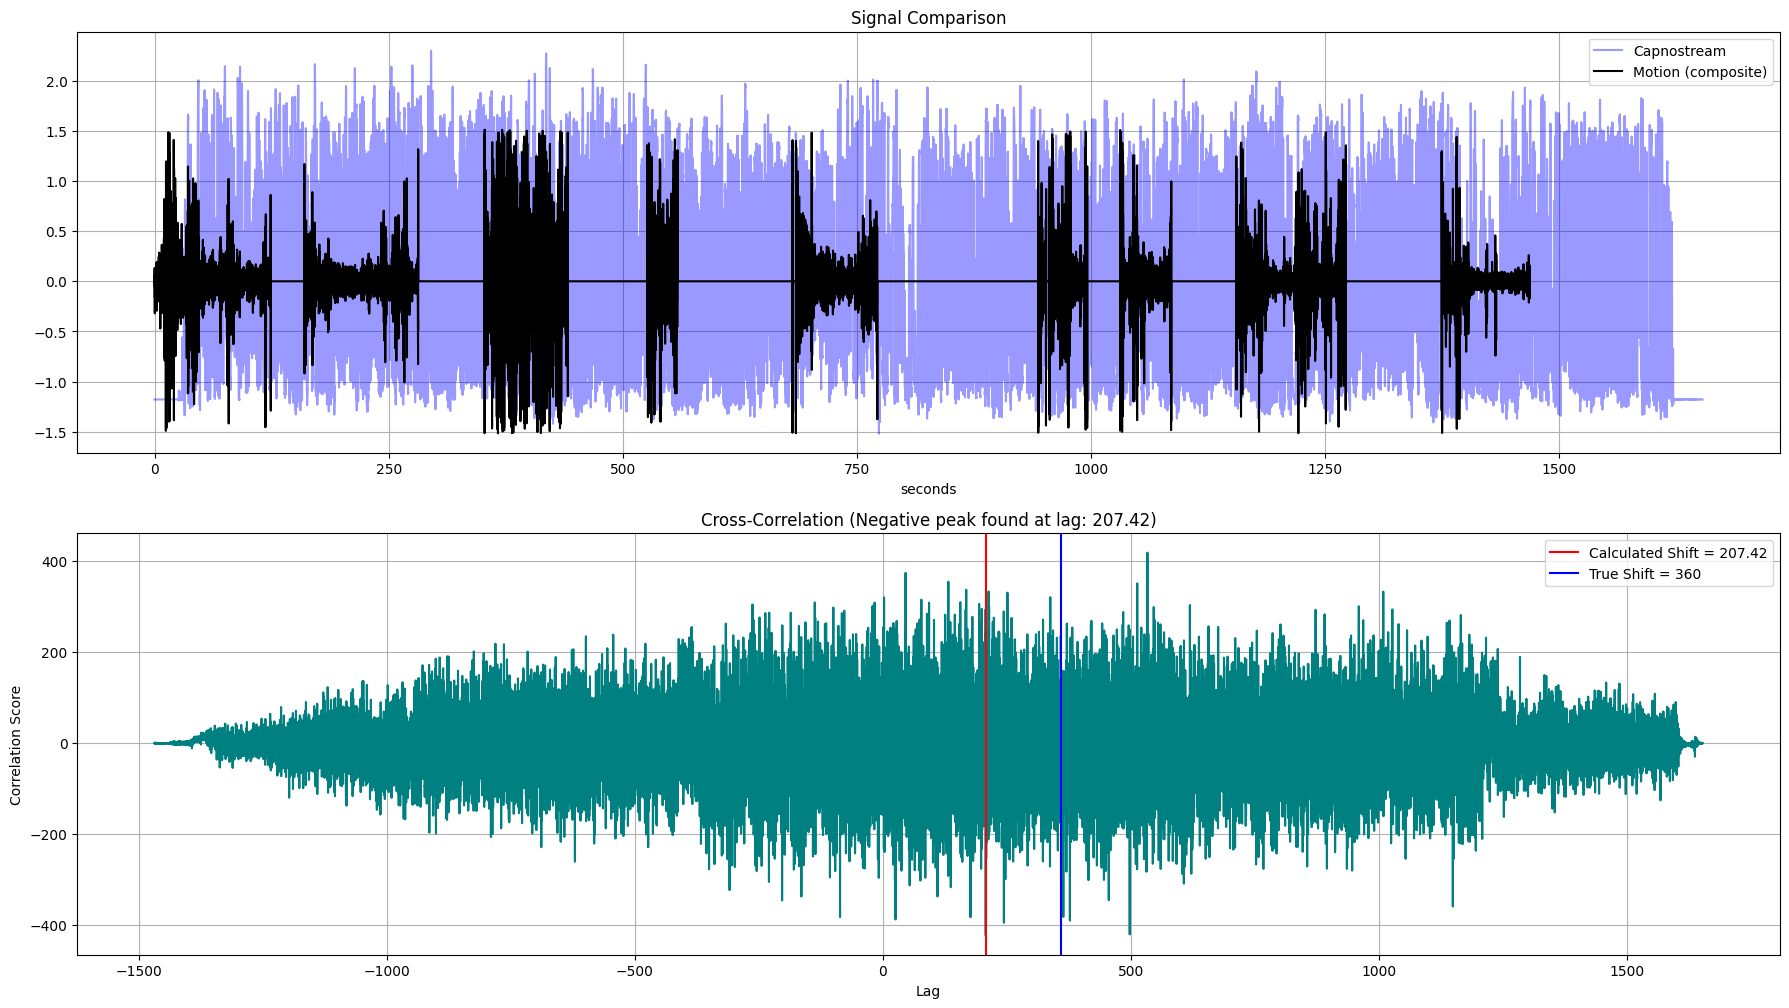

True Time Shift introduced: 360
Calculated Shift via Correlation (-422.77529281843874): 207.42
DL1 Z


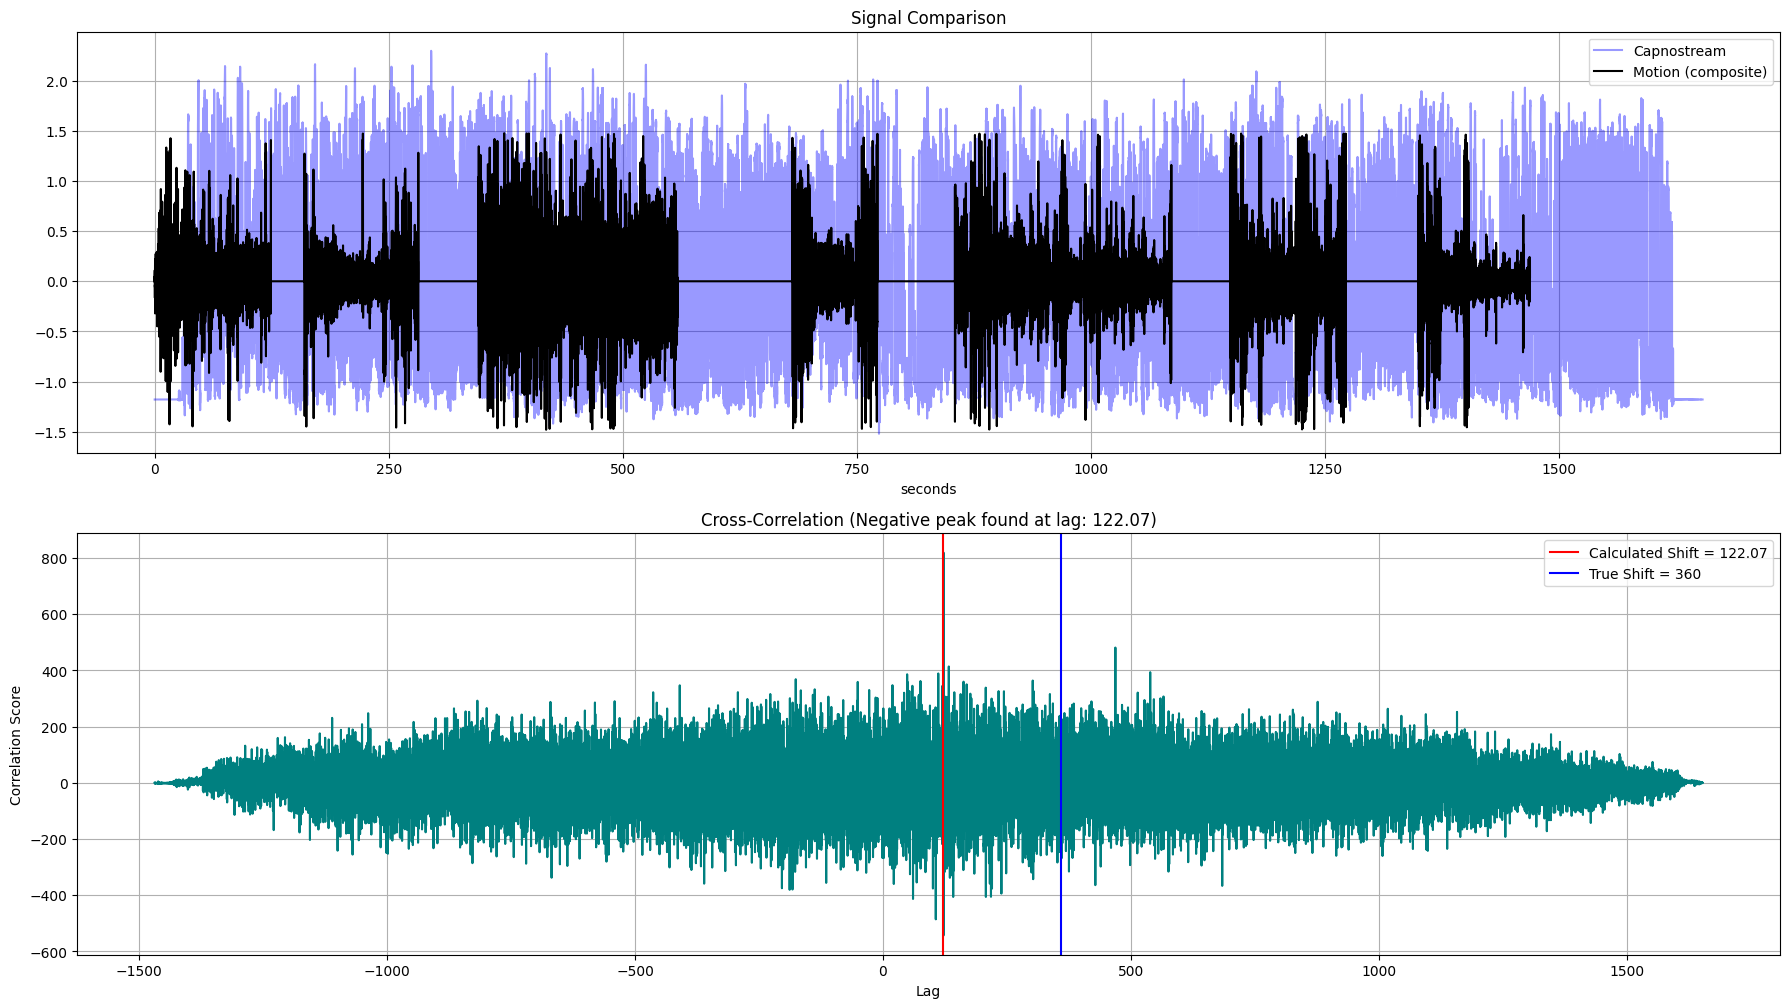

True Time Shift introduced: 360
Calculated Shift via Correlation (-543.8679678624351): 122.07
DL2 Z


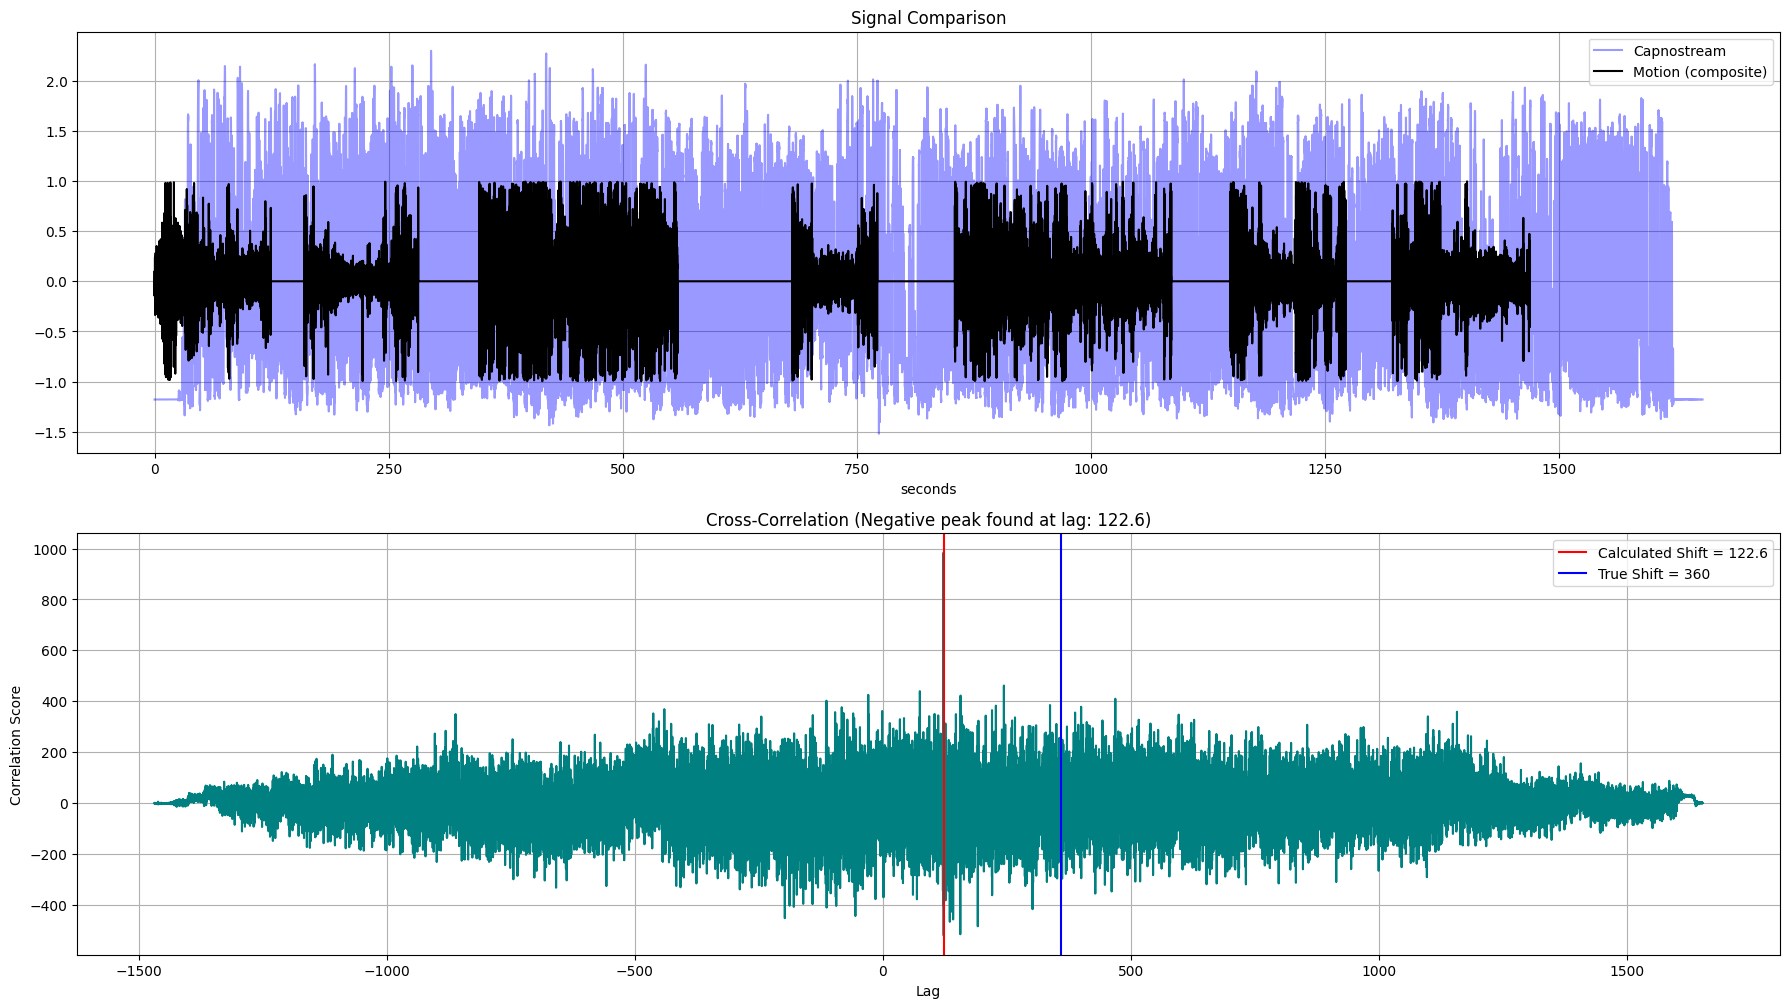

True Time Shift introduced: 360
Calculated Shift via Correlation (-520.7048836016573): 122.6
DR1 Z


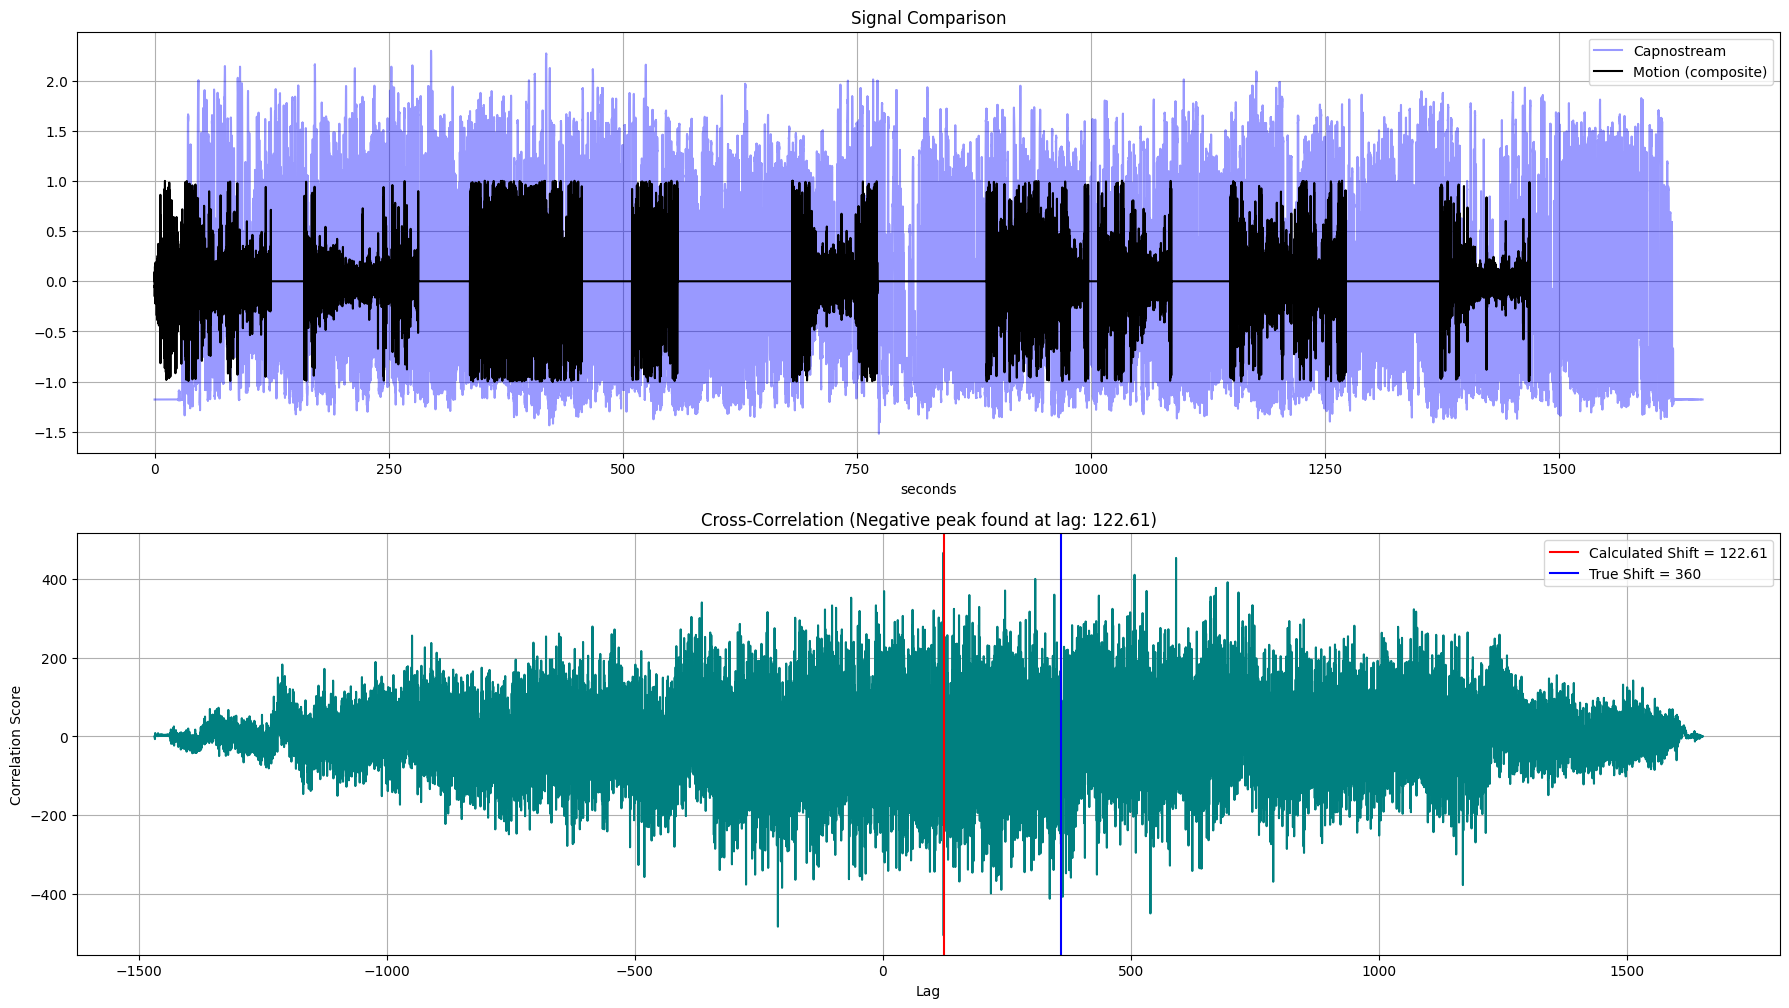

True Time Shift introduced: 360
Calculated Shift via Correlation (-505.89919978123663): 122.61
DR2 Z


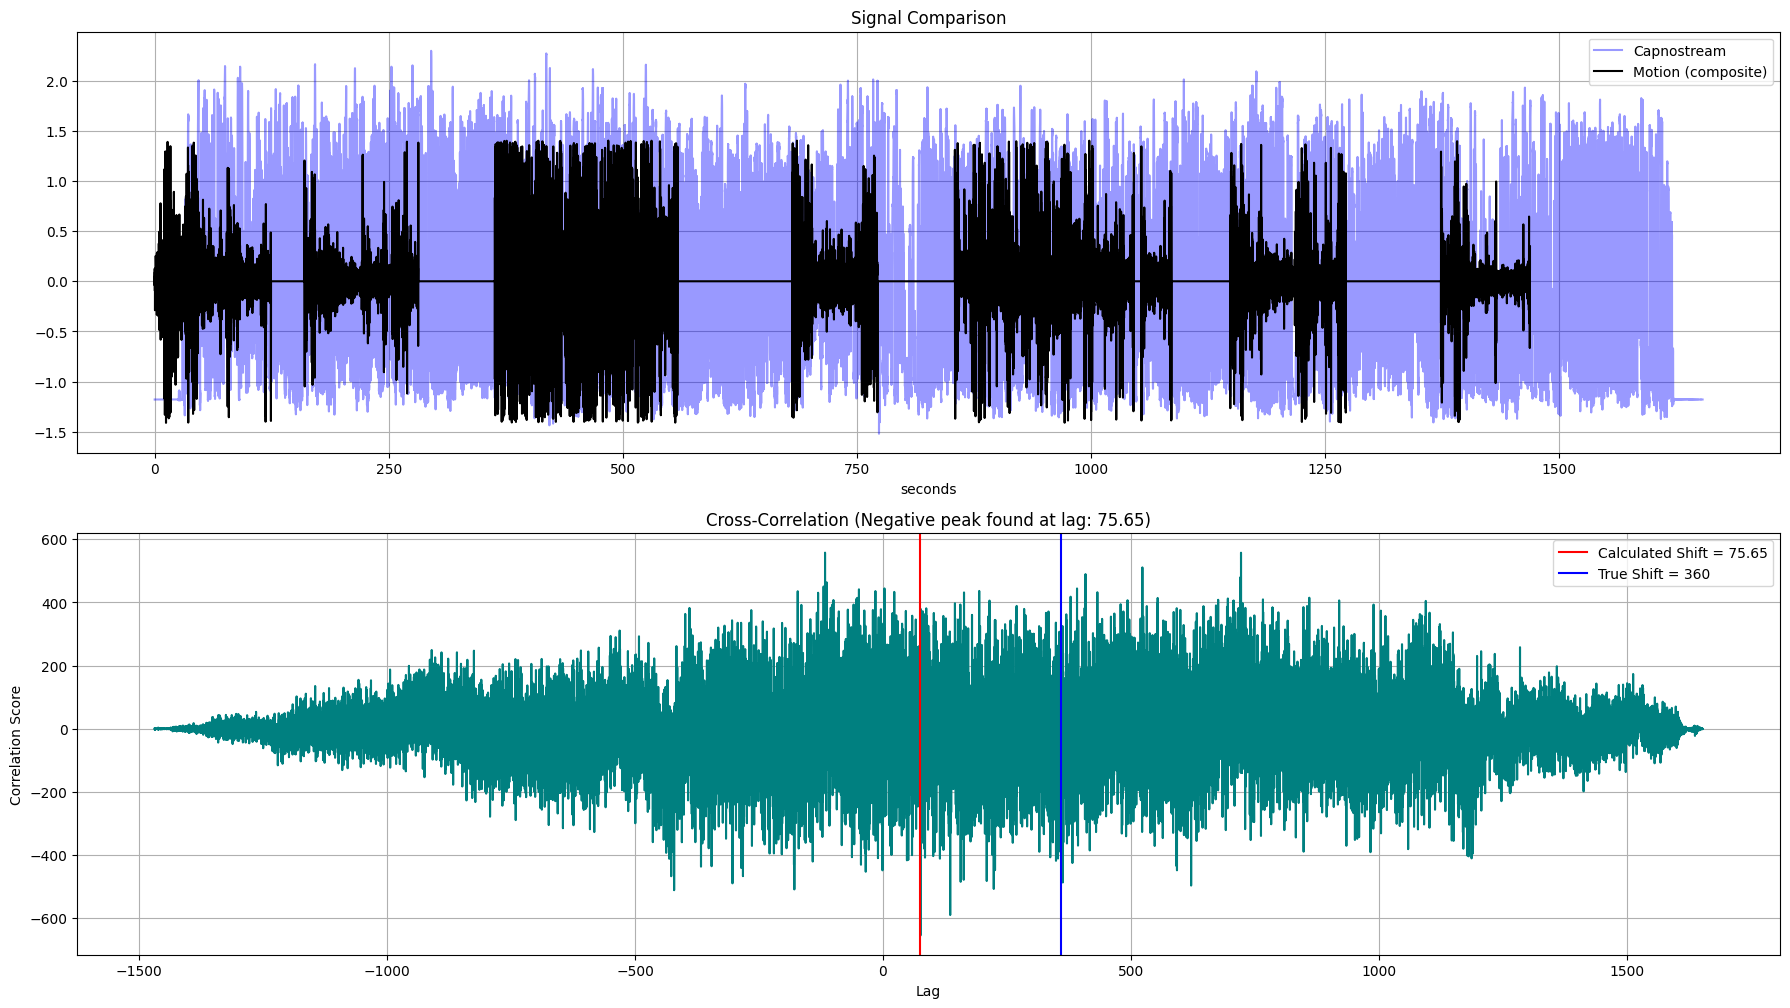

True Time Shift introduced: 360
Calculated Shift via Correlation (-655.6527321065366): 75.65


In [7]:

capnostream_sampling_rate = 20
TARGET_SHIFT = 360  # time (s) that motion capture must be offset by

for i, marker in enumerate(motions.columns):
    print(marker)
    align(motions[marker].to_numpy())